## Hypothesis 1: Demand and Entry-Level Access

This hypothesis examines whether demand for AI jobs differs across experience levels.

- Null Hypothesis (H0): The mean demand score is equal across experience levels.
- Alternative Hypothesis (H1): The mean demand score differs across experience levels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


df2 = pd.read_csv("ai_jobs_market_cleaned.csv")
df2.groupby("experience_level")["demand_score"].agg(["count", "mean", "std", "median", "min", "max"])

,count,mean,std,median,min,max
experience_level,,,,,,
Entry,385,87.059740,8.087031,88.0,68,98
Lead,381,87.992126,7.714132,90.0,68,98
Mid,370,87.218919,7.952649,89.0,68,98
Senior,364,87.832418,8.343318,90.0,68,98


### Descriptive Statistics for Demand Score by Experience Level

The table shows that the number of observations is fairly balanced across experience levels, which makes the comparison more reliable. Mean demand scores are very similar across all groups: entry-level roles have the lowest average demand score, while lead-level roles have the highest, but the differences are small overall.

The standard deviations are also close to one another, which suggests that demand scores have a similar spread across groups. Since the descriptive results show only slight differences, a formal hypothesis test is needed to determine whether these differences are statistically significant.

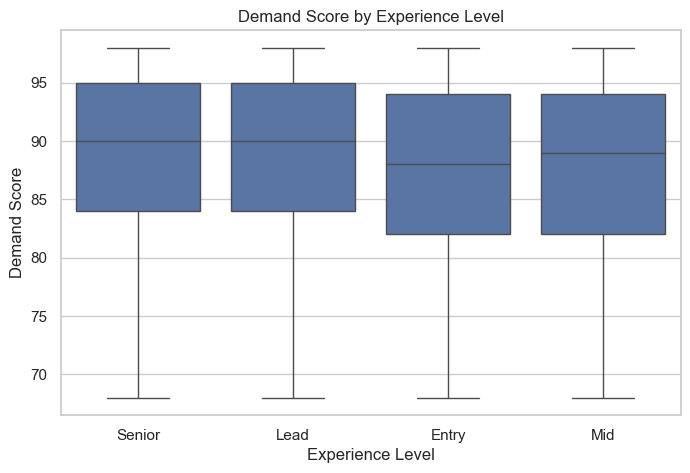

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df2,
    x="experience_level",
    y="demand_score"
)

plt.title("Demand Score by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Demand Score")

plt.show()

### Visualization of Demand Score by Experience Level

The boxplot shows that demand score distributions are highly similar across all experience levels. While Senior and Lead positions exhibit slightly higher median demand scores than Entry-level roles, the differences are small and visually overlapping.

The interquartile ranges and overall spread are nearly identical across groups, suggesting that variability in demand score is consistent regardless of experience level. Additionally, all groups share similar minimum and maximum values, indicating a common range of demand scores.

These observations suggest that any differences in demand across experience levels are subtle. Therefore, statistical testing is necessary to determine whether these differences are meaningful or due to random variation.

In [5]:
from statsmodels.stats.oneway import anova_oneway

# Create groups manually
groups = [
    df2[df2["experience_level"] == g]["demand_score"].values
    for g in df2["experience_level"].unique()
]

# Run Welch ANOVA
welch_result = anova_oneway(groups, use_var="unequal")

print(welch_result)

statistic = 1.235826989531814
pvalue = 0.2955593147787052
df = (3.0, np.float64(829.5463122900429))
df_num = 3.0
df_denom = 829.5463122900429
nobs_t = 1500.0
n_groups = 4
means = [87.83241758 87.99212598 87.05974026 87.21891892]
nobs = [364. 381. 385. 370.]
vars_ = [69.61095722 59.50783257 65.40006764 63.24462755]
use_var = unequal
welch_correction = True
tuple = (np.float64(1.235826989531814), np.float64(0.2955593147787052))
